### Matrix 
##### Dr. Quaife

#### Part(a)

Given that 
$$
f(\omega, \theta) = \dfrac{cos\omega cos\theta + sin\omega sin\theta - 1}{4(cos\omega - cos\theta)^2 + (sin\omega - sin\theta)^2}
$$
On Multiplying and dividing by -2 in Numerator and Denomenator

\begin{equation*}
\begin{aligned}
f(\omega, \theta) & = -\dfrac{1}{2} \cdot \dfrac{-2\cos\omega \cos\theta - 2 \sin\omega \cos\theta + 1 + 1}{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{-2\cos\omega \cos\theta - 2 \sin\omega \cos\theta + cos^2\omega + sin^2\omega + cos^2\theta + sin^2\theta }{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2}{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{1}{4 - 3 cos^2\left(\dfrac{\omega + \theta}{2}\right)} \\
\end{aligned}
\end{equation*}

On applying limits,

\begin{equation*}
\begin{aligned}
f(\omega, \theta) & = \dfrac{1}{2\left( 3cos^2\theta - 4 \right)} \\
\end{aligned}
\end{equation*}




### Part(b)

In [11]:
import numpy as np 
import matplotlib.pyplot as plt 

# defining the function f(omega , theta)
def f(omega, theta):
    if omega == theta: 
        return 1/(2 * (3*np.power(np.cos(theta), 2) - 4))
    else :
        return (np.cos(omega)*np.cos(theta) + np.sin(omega)*np.sin(theta) - 1)/( 4*(np.cos(omega) - np.cos(theta))**2 + (np.sin(omega) - np.sin(theta))**2)


In [12]:
# defining the function for matrix
def matrix(N):
    delta_theta = 2*np.pi/N 
    A = np.empty((N, N))

    for i in range(N):
        for j in range(N):
            omega_i = i * delta_theta
            omega_j = j * delta_theta
            A[i, j] = f(omega_i, omega_j)
    
    return A         

In [13]:
# Testing the functions
matrix(5)

array([[-0.5       , -0.24552235, -0.13464294, -0.13464294, -0.24552235],
       [-0.24552235, -0.13464294, -0.13464294, -0.24552235, -0.5       ],
       [-0.13464294, -0.13464294, -0.24552235, -0.5       , -0.24552235],
       [-0.13464294, -0.24552235, -0.5       , -0.24552235, -0.13464294],
       [-0.24552235, -0.5       , -0.24552235, -0.13464294, -0.13464294]])

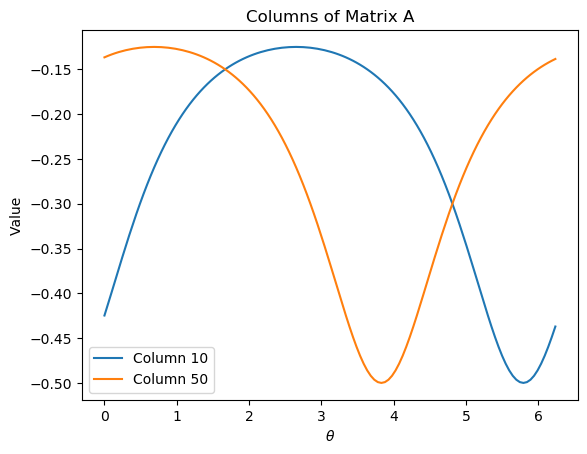

Matrix A is symmetric: True


In [14]:
def plot_columns(matrix, col_indices):
    N = matrix.shape[0]
    theta_values = np.linspace(0, 2 * np.pi, N, endpoint=False)

    for col_index in col_indices:
        plt.plot(theta_values, matrix[:, col_index], label=f"Column {col_index}")

    plt.xlabel(r"$\theta$")
    plt.ylabel("Value ")
    plt.title("Columns of Matrix A")
    plt.legend()
    plt.show()

def check_symmetric(matrix):
    return np.allclose(matrix, matrix.T)

N = 128
matrix_A = matrix(N)

# Plot the 10th and 50th columns of matrix A
plot_columns(matrix_A, [10, 50])

# Check if matrix A is symmetric
is_symmetric = check_symmetric(matrix_A)
print("Matrix A is symmetric:", is_symmetric)

#### Contour Plot of Matrix

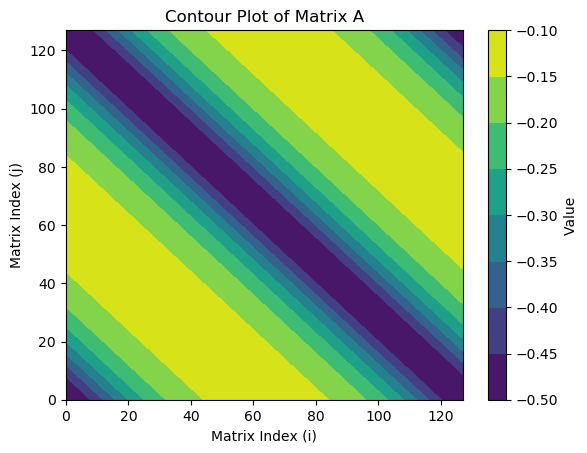

In [19]:
def plot_matrix_contour(matrix):
    N = matrix.shape[0]
    indices = np.arange(N)

    # Create a meshgrid for matrix indices
    x, y = np.meshgrid(indices, indices)

    # Create a contour plot of the matrix
    plt.contourf(x, y, matrix, cmap='viridis')
    plt.colorbar(label='Value')
    plt.xlabel("Matrix Index (i)")
    plt.ylabel("Matrix Index (j)")
    plt.title("Contour Plot of Matrix A")
    plt.show()

N = 128
matrix_A = matrix(N)

# Plot the contour plot of the entire matrix A with matrix indices on axes
plot_matrix_contour(matrix_A)


In [27]:
import numpy as np

def nofsingular(A, k, N):
    TOL = 1e-12
    Sol = np.zeros((k, k))
    dn = N // k

    for s in range(k):
        for h in range(k):
            S = np.linalg.svd(A[dn * s: dn * (s + 1), dn * h: dn * (h + 1)], compute_uv=False)
            number = np.sum(S > TOL)
            Sol[s, h] = number

    return Sol

# Example usage:
N = 8192

k = 8
matrix_A = matrix(N)  
result = nofsingular(matrix_A, k, N)
print(result)


[[1012.   14.    8.    7.    8.    9.   11.   22.]
 [  14.  985.   11.    8.    9.   11.   13.   11.]
 [   8.   11.  979.   14.   11.   13.   11.    9.]
 [   7.    8.   14. 1007.   22.   11.    9.    8.]
 [   8.    9.   11.   22. 1001.   14.    8.    7.]
 [   9.   11.   13.   11.   14.  975.   11.    8.]
 [  11.   13.   11.    9.    8.   11.  985.   14.]
 [  22.   11.    9.    8.    7.    8.   14. 1004.]]
